## Depedências

In [1]:
# !nvidia-smi
# !pip install --upgrade dataframe-image
# !pip install kaleido
# !apt install firefox firefox-geckodriver
# !pip install dataframe_image selenium
!apt install libgraphviz-dev
!pip install pygraphviz

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libgail-common libgail18 libgtk2.0-0 libgtk2.0-bin libgtk2.0-common
  libgvc6-plugins-gtk librsvg2-common libxdot4
Suggested packages:
  gvfs
The following NEW packages will be installed:
  libgail-common libgail18 libgraphviz-dev libgtk2.0-0 libgtk2.0-bin
  libgtk2.0-common libgvc6-plugins-gtk librsvg2-common libxdot4
0 upgraded, 9 newly installed, 0 to remove and 35 not upgraded.
Need to get 2,434 kB of archives.
After this operation, 7,681 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 libgtk2.0-common all 2.24.33-2ubuntu2.1 [125 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 libgtk2.0-0 amd64 2.24.33-2ubuntu2.1 [2,038 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 libgail18 amd64 2.24.33-2ubuntu2.1 [15.9 kB]
Get:4 http://archive.ubun

In [2]:
import kagglehub
import pickle
import os
import keras
import pydot
import re
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
# import dataframe_image as dfi
from networkx.drawing.nx_agraph import pygraphviz_layout
from PIL import Image
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten, Concatenate, Add, Softmax, Multiply
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Input, BatchNormalization
from tensorflow.keras.initializers import he_normal
from tensorflow.keras import optimizers
from tensorflow.keras.callbacks import LearningRateScheduler, TensorBoard, CSVLogger
from tensorflow.keras.utils import get_file
from tensorflow.keras import backend as K
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import optimizers
from tensorflow.keras.utils import plot_model
from tensorflow.keras.models import load_model
from tensorflow.keras.callbacks import CSVLogger
from tensorflow.keras.utils import set_random_seed
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from collections import defaultdict
from scipy import stats
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt

# Relations for Fashion MNIST
c2_to_c1 = {
    0:0, 1:0, 2:0,
    3:1, 4:1, 5:1,
    6:2, 7:2, 8:2,
    9:3, 10:3, 11:3,
}
fine_to_c2 = {
    0:0, 1:0, 2:0,
    3:1, 4:1, 5:1,
    6:2, 7:2, 8:2,
    9:3,
    10:4, 11:4, 12:4,
    13:5, 14:5, 15:5,
    16:6, 17:6, 18:6,
    19:7,
    20:8, 21:8, 22:8,
    23:9, 24:9, 25:9,
    26:10, 27:10, 28:10,
    29:11,
}

unique_fine = [*range(0, 30, 1)]
unique_c2 = np.vectorize(fine_to_c2.get)(unique_fine)
unique_c1 = np.vectorize(c2_to_c1.get)(unique_c2)

relations = []
for i in range(30):
  relations.append([unique_c1[i],unique_c2[i]+2,unique_fine[i]+8])

# Computes hierarchical metrics
def hierarchical_metrics(true,pred):
  true_labels = []
  true_fine = true[2].argmax(axis=1)+8
  true_c2 = true[1].argmax(axis=1)+2
  true_c1 = true[0].argmax(axis=1)
  for i in range(len(true_fine)):
    true_labels.append([true_c1[i],true_c2[i],true_fine[i]])
  pred_labels = []
  pred_c1 = pred[0].argmax(axis = 1)
  pred_c2 = pred[1].argmax(axis = 1)+2
  pred_fine = pred[2].argmax(axis = 1)+8
  for i in range(len(pred_c1)):
    pred_labels.append([pred_c1[i],pred_c2[i],pred_fine[i]])
  preci = precision(true_labels,pred_labels)
  reca = recall(true_labels,pred_labels)
  f_1 = f1(true_labels,pred_labels)

  consistent_examples = 1
  correct_pred = 0
  test_set_size = len(true_labels)
  for i in range(test_set_size):
    if [pred_c1[i],pred_c2[i],pred_fine[i]] in relations:
        consistent_examples = consistent_examples + 1
    if [pred_c1[i],pred_c2[i],pred_fine[i]] == true_labels[i]:
        correct_pred = correct_pred +1
  h_accuracy = correct_pred/test_set_size
  h_consistency = (consistent_examples-1)/test_set_size

  return h_accuracy,h_consistency,f_1

# Hierarchical metrics, proposed by Kiritchenko et al (2005)
# Implementation
# https://gitlab.com/dacs-hpi/hiclass/-/blob/main/hiclass/metrics.py


def precision(y_true: np.ndarray, y_pred: np.ndarray):
    """
    Compute precision score for hierarchical classification.

    hP = sum(|S intersection T|) / sum(|S|),
    where S is the set consisting of the most specific class(es) predicted for a test example and all respective ancestors
    and T is the set consisting of the true most specific class(es) for a test example and all respective ancestors.

    Parameters
    ----------
    y_true : np.array of shape (n_samples, n_levels)
        Ground truth (correct) labels.
    y_pred : np.array of shape (n_samples, n_levels)
        Predicted labels, as returned by a classifier.
    Returns
    -------
    precision : float
        What proportion of positive identifications was actually correct?
    """
    assert len(y_true) == len(y_pred)
    sum_intersection = 0
    sum_prediction_and_ancestors = 0
    for ground_truth, prediction in zip(y_true, y_pred):
        sum_intersection = sum_intersection + len(
            set(ground_truth).intersection(set(prediction))
        )
        sum_prediction_and_ancestors = sum_prediction_and_ancestors + len(
            set(prediction)
        )
    precision = sum_intersection / sum_prediction_and_ancestors
    return precision


def recall(y_true: np.ndarray, y_pred: np.ndarray):
    """
    Compute recall score for hierarchical classification.

    hR = sum(|S intersection T|) / sum(|T|),
    where S is the set consisting of the most specific class(es) predicted for a test example and all respective ancestors
    and T is the set consisting of the true most specific class(es) for a test example and all respective ancestors.

    Parameters
    ----------
    y_true : np.array of shape (n_samples, n_levels)
        Ground truth (correct) labels.
    y_pred : np.array of shape (n_samples, n_levels)
        Predicted labels, as returned by a classifier.
    Returns
    -------
    recall : float
        What proportion of actual positives was identified correctly?
    """
    assert len(y_true) == len(y_pred)
    sum_intersection = 0
    sum_prediction_and_ancestors = 0
    for ground_truth, prediction in zip(y_true, y_pred):
        sum_intersection = sum_intersection + len(
            set(ground_truth).intersection(set(prediction))
        )
        sum_prediction_and_ancestors = sum_prediction_and_ancestors + len(
            set(ground_truth)
        )
    recall = sum_intersection / sum_prediction_and_ancestors
    return recall


def f1(y_true: np.ndarray, y_pred: np.ndarray):
    """
    Compute f1 score for hierarchical classification.

    hF = 2 * hP * hR / (hP + hR),
    where hP is the hierarchical precision and hR is the hierarchical recall.

    Parameters
    ----------
    y_true : np.array of shape (n_samples, n_levels)
        Ground truth (correct) labels.
    y_pred : np.array of shape (n_samples, n_levels)
        Predicted labels, as returned by a classifier.
    Returns
    -------
    f1 : float
        Weighted average of the precision and recall
    """
    assert len(y_true) == len(y_pred)
    prec = precision(y_true, y_pred)
    rec = recall(y_true, y_pred)
    f1 = 2 * prec * rec / (prec + rec)
    return f1

## Configurações Gerais

In [3]:
# Baixa última versão do dataset
path = kagglehub.dataset_download("paramaggarwal/fashion-product-images-dataset")

print("Path to dataset files:", path)

100%|██████████| 23.1G/23.1G [03:45<00:00, 110MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/paramaggarwal/fashion-product-images-dataset/versions/1


In [5]:
# Carrega o arquivo de metadados
styles_csv_path = '/root/.cache/kagglehub/datasets/paramaggarwal/fashion-product-images-dataset/versions/1/fashion-dataset/styles.csv'
styles_df = pd.read_csv(styles_csv_path, on_bad_lines='skip')

#----------------------------Primeira filtragem pelo masterCategory----------------------------
# Conta as ocorrências da categoria master
master_category_counts = styles_df['masterCategory'].value_counts()

# Pega as 4 maiores
top_4_master_categories = master_category_counts.nlargest(4).index.tolist()

# Filtra pelas 4 maiores
filtered_styles_df = styles_df[styles_df['masterCategory'].isin(top_4_master_categories)]
#----------------------------Primeira filtragem----------------------------

#----------------------------Segunda filtragem pelo subCategory----------------------------
top_3_subcategories_per_master = {}
filtered_styles_df_by_top_subcategories = pd.DataFrame()

for master_cat in top_4_master_categories:
    # Filtra o dataframe por categoria principal
    df_master_cat = styles_df[styles_df['masterCategory'] == master_cat]

    # Obtenha as 3 subcategorias mais frequentes para esta categoria principal
    top_sub_categories = df_master_cat['subCategory'].value_counts().nlargest(3).index.tolist()
    top_3_subcategories_per_master[master_cat] = top_sub_categories

    # Filtra pelas 3 subcategorias
    df_filtered_sub = df_master_cat[df_master_cat['subCategory'].isin(top_sub_categories)]

    filtered_styles_df_by_top_subcategories = pd.concat([filtered_styles_df_by_top_subcategories, df_filtered_sub])
#----------------------------Segunda filtragem pelo subCategory----------------------------

#----------------------------Terceira filtragem----------------------------
top_3_article_types_per_subcategory = {}
dataset = pd.DataFrame()

# Iterate through the subcategories that are already filtered
for sub_cat in filtered_styles_df_by_top_subcategories['subCategory'].unique():
    df_sub_cat = filtered_styles_df_by_top_subcategories[filtered_styles_df_by_top_subcategories['subCategory'] == sub_cat]

    top_article_types = df_sub_cat['articleType'].value_counts().nlargest(3).index.tolist()
    top_3_article_types_per_subcategory[sub_cat] = top_article_types

    df_filtered_article = df_sub_cat[df_sub_cat['articleType'].isin(top_article_types)]

    dataset = pd.concat([dataset, df_filtered_article])
#----------------------------Terceira filtragem----------------------------
print(top_3_article_types_per_subcategory)

{'Topwear': ['Tshirts', 'Shirts', 'Kurtas'], 'Bottomwear': ['Jeans', 'Shorts', 'Trousers'], 'Innerwear': ['Briefs', 'Bra', 'Innerwear Vests'], 'Watches': ['Watches'], 'Bags': ['Handbags', 'Backpacks', 'Clutches'], 'Jewellery': ['Earrings', 'Pendant', 'Necklace and Chains'], 'Shoes': ['Casual Shoes', 'Sports Shoes', 'Heels'], 'Flip Flops': ['Flip Flops'], 'Sandal': ['Sandals', 'Sports Sandals', 'Flip Flops'], 'Fragrance': ['Perfume and Body Mist', 'Deodorant', 'Fragrance Gift Set'], 'Lips': ['Lipstick', 'Lip Gloss', 'Lip Liner'], 'Nails': ['Nail Polish']}


In [6]:
## Dimensões da imagem
height, width = 32, 32

channel = 3
if K.image_data_format() == 'channels_first':
    input_shape = (channel, height, width)
else:
    input_shape = (height, width, channel)

In [7]:
train_size = int(dataset.shape[0] * 0.70)
test_size = int(np.floor(dataset.shape[0] * 0.15))
val_size = int(np.ceil(dataset.shape[0] * 0.15))

train_df, temp_df = train_test_split(
    dataset,
    test_size=(val_size + test_size) / len(dataset),
    random_state=42,
    stratify=dataset['articleType']
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=test_size / (val_size + test_size),
    random_state=42,
    stratify=temp_df['articleType']
)


# Quantidade de classes no primeiro nível hierárquico camada
coarse1_classes = 4

# Quantidade de classes no segundo nível hierárquico camada
coarse2_classes = 12

# Quantidade de classes no último nível hierárquico (folhas da árvore)
num_classes  = 30

batch_size   = 128
epochs       = 100

In [8]:
def scheduler(epoch):
  learning_rate_init = 0.001
  if epoch > 55:
    learning_rate_init = 0.0002
  if epoch > 70:
    learning_rate_init = 0.00005
  return learning_rate_init

In [9]:
class LossWeightsModifier(keras.callbacks.Callback):
  def __init__(self, alpha, beta, gamma):
    self.alpha = alpha
    self.beta = beta
    self.gamma = gamma
    # customize your behavior
  def on_epoch_end(self, epoch, logs={}):
    if epoch == 15:
      K.set_value(self.alpha, 0.1)
      K.set_value(self.beta, 0.8)
      K.set_value(self.gamma, 0.1)
    if epoch == 25:
      K.set_value(self.alpha, 0.1)
      K.set_value(self.beta, 0.2)
      K.set_value(self.gamma, 0.7)
    if epoch == 35:
      K.set_value(self.alpha, 0)
      K.set_value(self.beta, 0)
      K.set_value(self.gamma, 1)

In [10]:
class_names =[
  "Tshirts",
  "Shirts",
  "Kurtas",
  "Jeans",
  "Shorts",
  "Trousers",
  "Briefs",
  "Bra",
  "Innerwear Vests",
  "Watches",
  "Handbags",
  "Backpacks",
  "Clutches",
  "Earrings",
  "Pendant",
  "Necklace and Chains",
  "Casual Shoes",
  "Sports Shoes",
  "Heels",
  "Flip Flops",
  "Sandals",
  "Sports Sandals",
  "Flip Flops",
  "Perfume and Body Mist",
  "Deodorant",
  "Fragrance Gift Set",
  "Lipstick",
  "Lip Gloss",
  "Lip Liner",
  "Nail Polish",
]

class_names_c1 = ['Apparel', 'Accessories','Footwear','Personal Care']
class_names_c2 = ['Topwear', 'Bottomwear', 'Innerwear', 'Watches', 'Bags', 'Jewellery', 'Shoes', 'Flip Flops', 'Sandal', 'Fragrance', 'Lips', 'Nails']

class_names_index = {class_name: index for index, class_name in enumerate(class_names)}

def print_mappings(mapping, source, dest):
    for k,v in mapping.items():
        print(source[k], "->", dest[v])

print_mappings(c2_to_c1, class_names_c2, class_names_c1)
print("-"*10)
print_mappings(fine_to_c2, class_names, class_names_c2)

Topwear -> Apparel
Bottomwear -> Apparel
Innerwear -> Apparel
Watches -> Accessories
Bags -> Accessories
Jewellery -> Accessories
Shoes -> Footwear
Flip Flops -> Footwear
Sandal -> Footwear
Fragrance -> Personal Care
Lips -> Personal Care
Nails -> Personal Care
----------
Tshirts -> Topwear
Shirts -> Topwear
Kurtas -> Topwear
Jeans -> Bottomwear
Shorts -> Bottomwear
Trousers -> Bottomwear
Briefs -> Innerwear
Bra -> Innerwear
Innerwear Vests -> Innerwear
Watches -> Watches
Handbags -> Bags
Backpacks -> Bags
Clutches -> Bags
Earrings -> Jewellery
Pendant -> Jewellery
Necklace and Chains -> Jewellery
Casual Shoes -> Shoes
Sports Shoes -> Shoes
Heels -> Shoes
Flip Flops -> Flip Flops
Sandals -> Sandal
Sports Sandals -> Sandal
Flip Flops -> Sandal
Perfume and Body Mist -> Fragrance
Deodorant -> Fragrance
Fragrance Gift Set -> Fragrance
Lipstick -> Lips
Lip Gloss -> Lips
Lip Liner -> Lips
Nail Polish -> Nails


In [11]:
#----------Pega os pesos do modelo VGG16 pré-treinado--------
WEIGHTS_PATH = 'https://github.com/fchollet/deep-learning-models/releases/download/v0.1/vgg16_weights_tf_dim_ordering_tf_kernels.h5'
weights_path = get_file(
    'vgg16_weights_tf_dim_ordering_tf_kernels.h5',
    WEIGHTS_PATH,
    cache_subdir='models',
)

# # Carregando os dados caso não tenha salvo anteriormente
# train_path = '/kaggle/input/fashion-product-images-dataset/fashion-dataset/images/'

# Inicializa listas de dados
x_train, y_train = [], []
x_test, y_test = [], []
x_val, y_val = [], []


# Carrega os dados salvos
with open('fashion_data.pkl', 'rb') as f:
    data = pickle.load(f)
    x_train = data['x_train']
    y_train = data['y_train']
    x_test = data['x_test']
    y_test = data['y_test']
    x_val = data['x_val']
    y_val = data['y_val']

# One Hot Encondig para as labels fine
train_labels_fine = to_categorical(y_train)
test_labels_fine = to_categorical(y_test)
val_labels_fine = to_categorical(y_val)

# One Hot Encoding para as labels da segunda camada grossa
train_labels_c2_index = [fine_to_c2[i] for i in y_train]
train_labels_c2 = to_categorical(train_labels_c2_index)

test_labels_c2_index = [fine_to_c2[i] for i in y_test]
test_labels_c2 = to_categorical(test_labels_c2_index)

val_labels_c2_index = [fine_to_c2[i] for i in y_val]
val_labels_c2 = to_categorical(val_labels_c2_index)

# One Hot Enconding para as labels da primeira camada grossa
train_labels_c1_index = [c2_to_c1[i] for i in train_labels_c2_index]
train_labels_c1 = to_categorical(train_labels_c1_index)

test_labels_c1_index = [c2_to_c1[i] for i in test_labels_c2_index]
test_labels_c1 = to_categorical(test_labels_c1_index)

val_labels_c1_index = [c2_to_c1[i] for i in val_labels_c2_index]
val_labels_c1 = to_categorical(val_labels_c1_index)

# Finalmente criando as variáveis labels para treino, teste e validação
y_train = train_labels_fine
y_test = test_labels_fine
y_val = val_labels_fine

y_c1_train = train_labels_c1
y_c1_test = test_labels_c1
y_c1_val = val_labels_c1

y_c2_train = train_labels_c2
y_c2_test = test_labels_c2
y_c2_val = val_labels_c2

# Coloca o Channel por último
x_train = x_train.transpose(0, 2, 3, 1)
x_test = x_test.transpose(0, 2, 3, 1)
x_val = x_val.transpose(0, 2, 3, 1)

print("x_train shape: ", x_train.shape)
print("x_test shape: ", x_test.shape)
print("x_val shape: ", x_val.shape)

print("y_train shape: ", y_train.shape)
print("y_test shape: ", y_test.shape)
print("y_val shape: ", y_val.shape)

print("y_c1_train shape: ", y_c1_train.shape)
print("y_c1_test shape: ", y_c1_test.shape)
print("y_c1_val shape: ", y_c1_val.shape)

print("y_c2_train shape: ", y_c2_train.shape)
print("y_c2_test shape: ", y_c2_test.shape)
print("y_c2_val shape: ", y_c2_val.shape)

# Transforma o id das imagens para indices
# id_to_index = {image_id: index for index, image_id in enumerate(dataset['id'])}

# Loop para carregar imagens com shape fixo (3, 32, 32)
# for image_id in dataset['id']:
#     image_filename = str(image_id) + '.jpg'
#     image_path = os.path.join(train_path, image_filename)

#     if os.path.exists(image_path):
#         dataset_index = id_to_index[image_id]

#         img = Image.open(image_path).convert("RGB")  # Garante 3 canais
#         img = img.resize((width, height))
#         img_array = np.array(img)

#         if image_id in train_df['id'].values:
#             x_train.append(img_array)
#             y_train.append(class_names_index[dataset.iloc[dataset_index]['articleType']])

#         elif image_id in test_df['id'].values:
#             x_test.append(img_array)
#             y_test.append(class_names_index[dataset.iloc[dataset_index]['articleType']])

#         elif image_id in val_df['id'].values:
#             x_val.append(img_array)
#             y_val.append(class_names_index[dataset.iloc[dataset_index]['articleType']])

# x_train = np.array(x_train).transpose(0, 3, 1, 2).astype("float32")
# x_test = np.array(x_test).transpose(0, 3, 1, 2).astype("float32")
# x_val = np.array(x_val).transpose(0, 3, 1, 2).astype("float32")

# x_train = (x_train - np.mean(x_train)) / np.std(x_train)
# x_test = (x_test - np.mean(x_test)) / np.std(x_test)
# x_val = (x_val - np.mean(x_val)) / np.std(x_val)

# y_train = np.array(y_train)
# y_test = np.array(y_test)
# y_val = np.array(y_val)

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 9s 0us/step
x_train shape:  (21955, 32, 32, 3)
x_test shape:  (4705, 32, 32, 3)
x_val shape:  (4704, 32, 32, 3)
y_train shape:  (21955, 30)
y_test shape:  (4705, 30)
y_val shape:  (4704, 30)
y_c1_train shape:  (21955, 4)
y_c1_test shape:  (4705, 4)
y_c1_val shape:  (4704, 4)
y_c2_train shape:  (21955, 12)
y_c2_test shape:  (4705, 12)
y_c2_val shape:  (4704, 12)


# BA-CNN

In [ ]:
# Best Hypeparameters
# if True, the model uses BT-strategy for training
bt_strategy = True

# neurons of all dense layers on each branch
branch_neurons = 16    # Parsimonious version 256

att_neurons = 2048     # Parsimonious version 64

In [ ]:
#----------------------- model definition ---------------------------
if bt_strategy == True:
  alpha = K.variable(value=0.98, dtype="float32", name="alpha") # A1 in paper
  beta = K.variable(value=0.01, dtype="float32", name="beta") # A2 in paper
  gamma = K.variable(value=0.01, dtype="float32", name="gamma") # A3 in paper
else:
  alpha = K.variable(value=0.33, dtype="float32", name="alpha") # A1 in paper
  beta = K.variable(value=0.33, dtype="float32", name="beta") # A2 in paper
  gamma = K.variable(value=0.34, dtype="float32", name="gamma") # A3 in paper

img_input = Input(shape=input_shape, name='input')
#block 1
x = Conv2D(64, (3, 3), activation='relu', padding='same')(img_input)
x = BatchNormalization()(x)
x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2), strides=(2, 2))(x)

#block 2
x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2), strides=(2, 2))(x)

#coarse 1
c_1_bch = Flatten(name='c1_flatten')(x)
c_1_bch = Dense(branch_neurons, activation='relu')(c_1_bch)
c_1_bch = BatchNormalization()(c_1_bch)
c_1_bch = Dropout(0.5)(c_1_bch)
c_1_bch = Dense(branch_neurons, activation='relu')(c_1_bch)
c_1_bch = BatchNormalization()(c_1_bch)
c_1_bch = Dropout(0.5)(c_1_bch)
#c_1_pred = Dense(coarse1_classes, activation='softmax')(c_1_bch)

#block 3
x = Conv2D(256, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = Conv2D(256, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = Conv2D(256, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2), strides=(2, 2))(x)

#coarse 2
c_2_bch = Flatten(name='c2_flatten')(x)
c_2_bch = Dense(branch_neurons, activation='relu')(c_2_bch)
c_2_bch = BatchNormalization()(c_2_bch)
c_2_bch = Dropout(0.5)(c_2_bch)
c_2_bch = Dense(branch_neurons, activation='relu')(c_2_bch)
c_2_bch = BatchNormalization()(c_2_bch)
c_2_bch = Dropout(0.5)(c_2_bch)

#block 4
x = Conv2D(512, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = Conv2D(512, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = Conv2D(512, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2), strides=(2, 2))(x)

#block 5
x = Conv2D(512, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = Conv2D(512, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = Conv2D(512, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)

#fine
x = Flatten(name='flatten')(x)
x = Dense(branch_neurons, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(branch_neurons, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)

#-- Att for coarse 1---
# Coarse 1
sfcn_1_1 = Dense(att_neurons, name='fc1_1')(c_1_bch)
sfcn_1_1 = Dense(1, name='fc1_2')(sfcn_1_1)
# Coarse 2
sfcn_1_2 = Dense(att_neurons, name='fc1_3')(c_2_bch)
sfcn_1_2 = Dense(1, name='fc1_4')(sfcn_1_2)
# Fine
sfcn_1_3 = Dense(att_neurons, name='fc1_5')(x)
sfcn_1_3 = Dense(1, name='fc1_6')(sfcn_1_3)

score_vector_1 = Concatenate()([sfcn_1_1,sfcn_1_2,sfcn_1_3]) # Score vector 1
att_weights_1 = Activation('softmax', name='attention_weights_1')(score_vector_1) # Attention weights 1

weighted_c1_bch_1 = Multiply()([c_1_bch, att_weights_1[:, 0:1]])
weighted_c2_bch_1 = Multiply()([c_2_bch, att_weights_1[:, 1:2]])
weighted_x_1 = Multiply()([x, att_weights_1[:, 2:3]])

weightned_sum_1 = Add()([weighted_c1_bch_1, weighted_c2_bch_1, weighted_x_1]) # Weightned sum 1

# Concat and prediction
coarse_1_concat = Concatenate()([c_1_bch,weightned_sum_1])
c_1_pred = Dense(coarse1_classes, activation='softmax', name='c1_predictions_clothes')(coarse_1_concat)

#-- Att for coarse 2---

# Coarse 1
sfcn_2_1 = Dense(att_neurons, name='fc2_1')(c_1_bch)
sfcn_2_1 = Dense(1, name='fc2_2')(sfcn_2_1)
# Coarse 2
sfcn_2_2 = Dense(att_neurons, name='fc2_3')(c_2_bch)
sfcn_2_2 = Dense(1, name='fc2_4')(sfcn_2_2)
# Fine
sfcn_2_3 = Dense(att_neurons, name='fc2_5')(x)
sfcn_2_3 = Dense(1, name='fc2_6')(sfcn_2_3)

score_vector_2 = Concatenate()([sfcn_2_1,sfcn_2_2,sfcn_2_3]) # Score vector 1
att_weights_2 = Activation('softmax', name='attention_weights_2')(score_vector_2) # Attention weights 1

weighted_c1_bch_2 = Multiply()([c_1_bch, att_weights_2[:, 0:1]])
weighted_c2_bch_2 = Multiply()([c_2_bch, att_weights_2[:, 1:2]])
weighted_x_2 = Multiply()([x, att_weights_2[:, 2:3]])

weightned_sum_2 = Add()([weighted_c1_bch_2, weighted_c2_bch_2, weighted_x_2]) # Weightned sum 1

# Concat and prediction
coarse_2_concat = Concatenate()([c_2_bch,weightned_sum_2])
c_2_pred = Dense(coarse2_classes, activation='softmax', name='c2_predictions_clothes')(coarse_2_concat)

#-- Att for fine---
# Coarse 1
sfcn_3_1 = Dense(att_neurons, name='fc3_1')(c_1_bch)
sfcn_3_1 = Dense(1, name='fc3_2')(sfcn_3_1)
# Coarse 2
sfcn_3_2 = Dense(att_neurons, name='fc3_3')(c_2_bch)
sfcn_3_2 = Dense(1, name='fc3_4')(sfcn_3_2)
# Fine
sfcn_3_3 = Dense(att_neurons, name='fc3_5')(x)
sfcn_3_3 = Dense(1, name='fc3_6')(sfcn_3_3)

score_vector_3 = Concatenate()([sfcn_3_1,sfcn_3_2,sfcn_3_3]) # Score vector 1
att_weights_3 = Activation('softmax', name='attention_weights_3')(score_vector_3) # Attention weights 1

weighted_c1_bch_3 = Multiply()([c_1_bch, att_weights_3[:, 0:1]])
weighted_c2_bch_3 = Multiply()([c_2_bch, att_weights_3[:, 1:2]])
weighted_x_3 = Multiply()([x, att_weights_3[:, 2:3]])

weightned_sum_3 = Add()([weighted_c1_bch_3, weighted_c2_bch_3, weighted_x_3]) # Weightned sum 3

# Concat and prediction
fine_concat = Concatenate()([x,weightned_sum_3])
fine_pred = Dense(num_classes, activation='softmax', name='predictions_clothes')(fine_concat)

model = Model(img_input, [c_1_pred, c_2_pred, fine_pred], name='bacnn')

#----------------------- compile and fit ---------------------------
sgd = optimizers.SGD(learning_rate=0.0002, momentum=0.9, nesterov=True)
model.compile(loss=['categorical_crossentropy', 'categorical_crossentropy', 'categorical_crossentropy'],
              optimizer=sgd,
              loss_weights=[alpha, beta, gamma],
              metrics=['accuracy', 'accuracy', 'accuracy'])
model.summary()

Model: "bacnn"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 32, 32, 3) │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_65 (Conv2D)  │ (None, 32, 32,    │      1,792 │ input[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_65[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_66 (Conv2D)  │ (None, 32, 32,    │     36,928 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_66[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_20    │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_67 (Conv2D)  │ (None, 16, 16,    │     73,856 │ max_pooling2d_20… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        512 │ conv2d_67[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_68 (Conv2D)  │ (None, 16, 16,    │    147,584 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        512 │ conv2d_68[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_21    │ (None, 8, 8, 128) │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_69 (Conv2D)  │ (None, 8, 8, 256) │    295,168 │ max_pooling2d_21… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 256) │      1,024 │ conv2d_69[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_70 (Conv2D)  │ (None, 8, 8, 256) │    590,080 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 256) │      1,024 │ conv2d_70[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_71 (Conv2D)  │ (None, 8, 8, 256) │    590,080 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 256) │      1,024 │ conv2d_71[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_22    │ (None, 4, 4, 256) │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │                   │            │                 

 Total params: 15,295,511 (58.35 MB)

 Trainable params: 15,286,871 (58.31 MB)

 Non-trainable params: 8,640 (33.75 KB)

In [ ]:
# Callbacks
change_lr = LearningRateScheduler(scheduler)
change_lw = LossWeightsModifier(alpha, beta, gamma)

if bt_strategy == True:
  cbks = [change_lr, change_lw]
else:
  cbks = [change_lr]

# Continue training
history_bcnn = model.fit(
    x_train, [y_c1_train, y_c2_train, y_train],
    batch_size=batch_size,
    epochs=epochs,
    verbose=1,
    callbacks=cbks,
    validation_data=(x_val, [y_c1_val, y_c2_val, y_val]),
)

score_ba_cnn_c = model.evaluate(x_test, [y_c1_test, y_c2_test, y_test], verbose=0)
parameters_ba_cnn_c = np.sum([K.count_params(w) for w in model.trainable_weights])

predictions = model.predict(x_test)
acc_ba_cnn_c, cons_ba_cnn_c, f1_ba_cnn_c= hierarchical_metrics([y_c1_test, y_c2_test, y_test],predictions)

# Save model
model.save("ba_cnn_base.keras")

# Save results to file
with open('results_ba_cnn_base.txt', 'w') as f:  # New file for BA-CNN
  f.write("--- BA-CNN Base C ---\n")
  f.write(f"Accuracy level 1: {score_ba_cnn_c[4]}\n")
  f.write(f"Accuracy level 2: {score_ba_cnn_c[5]}\n")
  f.write(f"Accuracy level 3: {score_ba_cnn_c[6]}\n")
  f.write(f"Hierarchical Accuracy: {acc_ba_cnn_c}\n")
  f.write(f"Consistency: {cons_ba_cnn_c}\n")
  f.write(f"F1: {f1_ba_cnn_c}\n")
  f.write(f"Parameters: {parameters_ba_cnn_c:,}\n")

# Results
print("--- BA-CNN Base C ---")
print("--- Accuracy per level ---")
print("Accuracy level 1:",score_ba_cnn_c[4])
print("Accuracy level 2:",score_ba_cnn_c[5])
print("Accuracy level 3:",score_ba_cnn_c[6])
print("--- Hierarchical Metrics ---")
print("Accuracy:",acc_ba_cnn_c)
print("Consistency:",cons_ba_cnn_c)
print("f1:",f1_ba_cnn_c)
print("Parameters:","{:,}".format(parameters_ba_cnn_c))

Epoch 1/100
172/172 ━━━━━━━━━━━━━━━━━━━━ 49s 168ms/step - c1_predictions_clothes_accuracy: 0.6627 - c1_predictions_clothes_loss: 0.9118 - c2_predictions_clothes_accuracy: 0.1272 - c2_predictions_clothes_loss: 3.0026 - loss: 0.9640 - predictions_clothes_accuracy: 0.0334 - predictions_clothes_loss: 4.0464 - val_c1_predictions_clothes_accuracy: 0.8695 - val_c1_predictions_clothes_loss: 0.8254 - val_c2_predictions_clothes_accuracy: 0.0130 - val_c2_predictions_clothes_loss: 2.7570 - val_loss: 0.8684 - val_predictions_clothes_accuracy: 0.0227 - val_predictions_clothes_loss: 3.4508 - learning_rate: 0.0010
Epoch 2/100
172/172 ━━━━━━━━━━━━━━━━━━━━ 16s 76ms/step - c1_predictions_clothes_accuracy: 0.9126 - c1_predictions_clothes_loss: 0.2990 - c2_predictions_clothes_accuracy: 0.1423 - c2_predictions_clothes_loss: 2.8779 - loss: 0.3616 - predictions_clothes_accuracy: 0.0349 - predictions_clothes_loss: 3.9798 - val_c1_predictions_clothes_accuracy: 0.9634 - val_c1_predictions_clothes_loss: 0.2129 - 

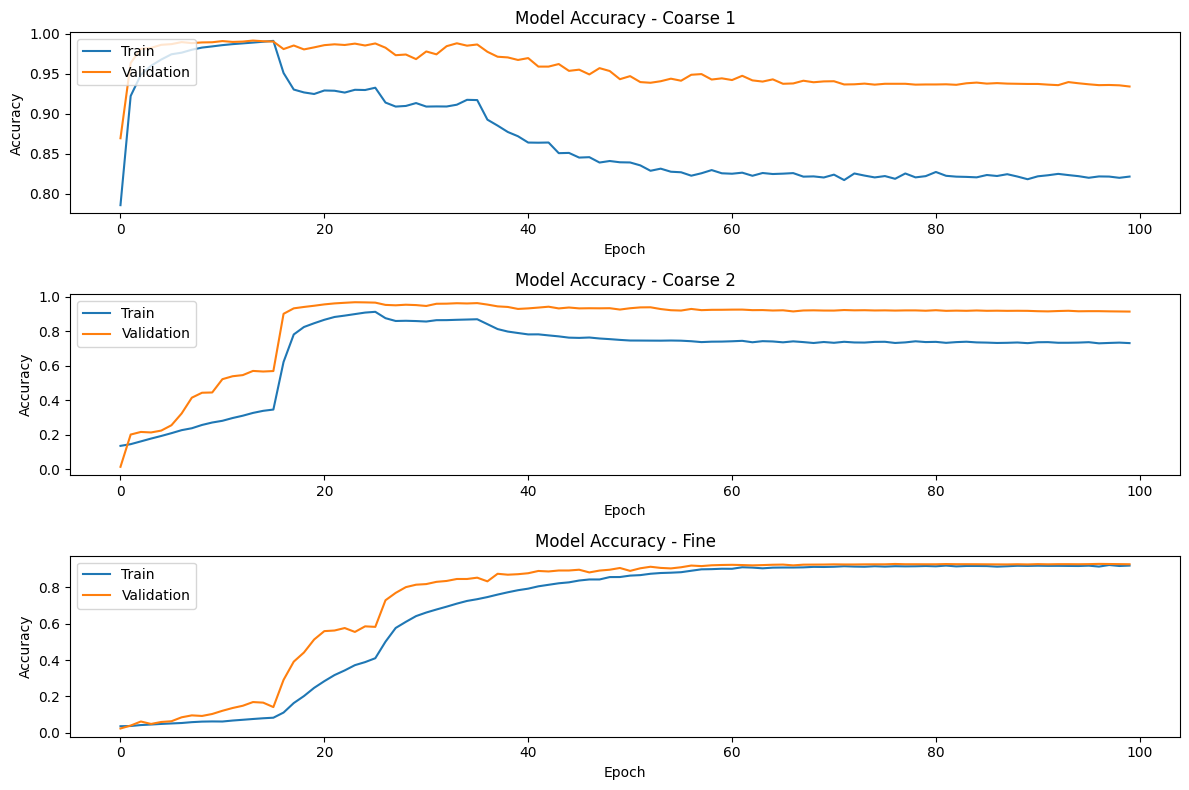

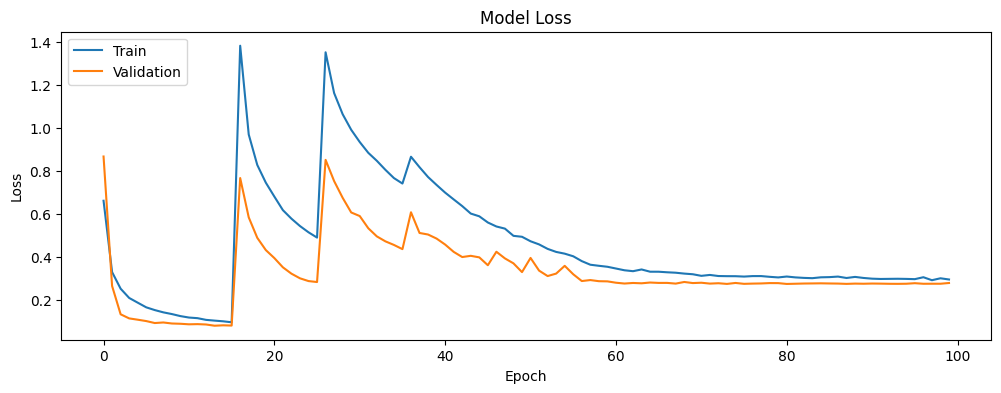

In [ ]:
# print(history_bcnn.history.keys())

plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.plot(history_bcnn.history['c1_predictions_clothes_accuracy'])
plt.plot(history_bcnn.history['val_c1_predictions_clothes_accuracy'])
plt.title('Model Accuracy - Coarse 1')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.subplot(3, 1, 2)
plt.plot(history_bcnn.history['c2_predictions_clothes_accuracy'])
plt.plot(history_bcnn.history['val_c2_predictions_clothes_accuracy'])
plt.title('Model Accuracy - Coarse 2')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.subplot(3, 1, 3)
plt.plot(history_bcnn.history['predictions_clothes_accuracy'])
plt.plot(history_bcnn.history['val_predictions_clothes_accuracy'])
plt.title('Model Accuracy - Fine')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

# Plot training & validation loss values
plt.figure(figsize=(12, 4))
plt.plot(history_bcnn.history['loss'])
plt.plot(history_bcnn.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Árvore Hierárquica

In [21]:
# # Carrega o modelo
# model = load_model('ba_cnn_base.keras')

# # Analisa o que o modelo prediziu
# preds = model.predict(x_test, batch_size=32)

# c1_preds = np.argmax(preds[0], axis=1)
# c2_preds = np.argmax(preds[1], axis=1)
# fine_preds = np.argmax(preds[2], axis=1)

# Cria a estrutura do Grafo, nesse caso é um grafo unidirecional
G = nx.DiGraph()

# Adiciona os nós iniciais
G.add_node("Root")
G.add_node("Apparel")
G.add_node("Accessories")
G.add_node("Footwear")
G.add_node("Personal Care")

# Adiciona as ligações entre o nós raiz e os demais da primeira camada
G.add_edges_from([("Root", "Apparel"),("Root", "Accessories"),("Root", "Footwear"),("Root", "Personal Care")])

# Adiciona as ligações entre os nós da primeira camada com os da segunda camada
excluded_classes = ["Watches", "Flip Flops", "Bra"]
for c1_pred, c2_pred in zip(c1_preds, c2_preds):
    if class_names_c1[c1_pred] in excluded_classes or class_names_c2[c2_pred] in excluded_classes:
        continue
    G.add_edge(class_names_c1[c1_pred], class_names_c2[c2_pred])

# Adiciona as ligações entre os nós da segunda camada com os da terceira camada já com a ponderação
for c2_pred, fine_pred in zip(c2_preds, fine_preds):
    if class_names_c2[c2_pred] in excluded_classes or class_names[fine_pred] in excluded_classes:
        continue
    G.add_edge(class_names_c2[c2_pred], class_names[fine_pred])

defaultdict(<class 'int'>, {('Apparel', 'Topwear'): 1848, ('Footwear', 'Topwear'): 27, ('Apparel', 'Bags'): 9, ('Apparel', 'Bottomwear'): 258, ('Apparel', 'Innerwear'): 191, ('Footwear', 'Innerwear'): 12, ('Footwear', 'Shoes'): 847, ('Accessories', 'Watches'): 375, ('Apparel', 'Watches'): 2, ('Accessories', 'Topwear'): 6, ('Accessories', 'Bags'): 406, ('Footwear', 'Bags'): 5, ('Accessories', 'Jewellery'): 81, ('Apparel', 'Jewellery'): 15, ('Accessories', 'Bottomwear'): 1, ('Footwear', 'Jewellery'): 16, ('Accessories', 'Fragrance'): 12, ('Accessories', 'Sandal'): 33, ('Footwear', 'Sandal'): 407, ('Footwear', 'Fragrance'): 2, ('Apparel', 'Fragrance'): 9, ('Personal Care', 'Shoes'): 2, ('Apparel', 'Sandal'): 7, ('Personal Care', 'Fragrance'): 122, ('Personal Care', 'Bags'): 1, ('Footwear', 'Lips'): 4, ('Footwear', 'Nails'): 7, ('Topwear', 'Tshirts'): 1116, ('Topwear', 'Shirts'): 457, ('Topwear', 'Kurtas'): 274, ('Topwear', 'Watches'): 6, ('Bags', 'Handbags'): 276, ('Topwear', 'Shorts'): 3

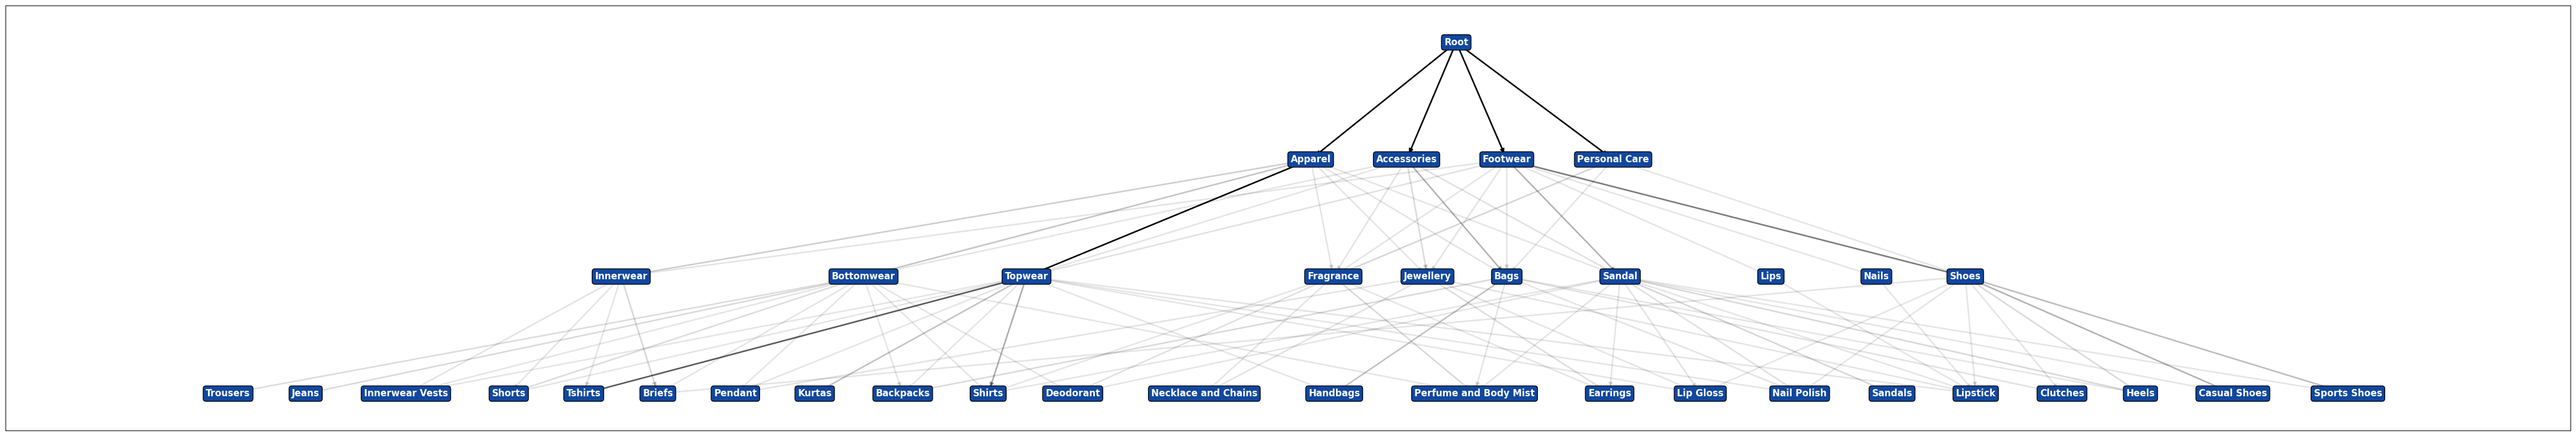

In [35]:
# Define o tamanhho da imagem
plt.figure(figsize=(60, 10))

edge_counts = defaultdict(int)

# prediction_paths = []
for c1_pred, c2_pred in zip(c1_preds, c2_preds):
    edge_counts[(class_names_c1[c1_pred], class_names_c2[c2_pred])] += 1

for c2_pred, fine_pred in zip(c2_preds, fine_preds):
    edge_counts[(class_names_c2[c2_pred], class_names[fine_pred])] += 1

# Define a layout do Grafo como uma árvore
pos = pygraphviz_layout(G, prog="dot")

# Desenha os nós da árvore
nx.draw_networkx_nodes(G, pos, node_color="#11479f")

# Desenha os nomes dos nós
nx.draw_networkx_labels(
    G,
    pos,
    font_color="white",
    font_weight="bold",
    bbox=dict(boxstyle="round,pad=0.3", fc="#11479f"),
)

# Desenha as conexões entre os nós
edges = list(G.edges())
alphas = []
max_count = max(edge_counts.values())

for edge in edges:
    if edge in [('Root', 'Apparel'), ('Root', 'Accessories'), ('Root', 'Footwear'), ('Root', 'Personal Care')]:
        alphas.append(1)
        continue

    alpha = 0.1 + 0.9 * (edge_counts[edge] / max_count)
    alphas.append(alpha)

nx.draw_networkx_edges(G, pos, edge_color="black", edgelist=edges, alpha=alphas, width=2)

# Plota a árvore
plt.show()

# # Salva a imagem na árvore em um arquivo
# plt.savefig("hierarchical_graph.png")

# Resultados

## BACNN

In [ ]:
folder_path = './results/bacnn'  # Change this to your folder path

data = []

patterns = {
    "Accuracy level 1": r"Accuracy level 1:\s+([0-9.]+)",
    "Accuracy level 2": r"Accuracy level 2:\s+([0-9.]+)",
    "Accuracy level 3": r"Accuracy level 3:\s+([0-9.]+)",
    "Hierarchical Accuracy": r"Hierarchical Accuracy:\s+([0-9.]+)",
    "Consistency": r"Consistency:\s+([0-9.]+)",
    "F1": r"F1:\s+([0-9.]+)",
    "Parameters": r"Parameters:\s+([\d,]+)"
}

for filename in os.listdir(folder_path):
    if filename.endswith('.txt'):
        filepath = os.path.join(folder_path, filename)
        with open(filepath, 'r') as file:
            content = file.read()
            row = {}
            for key, pattern in patterns.items():
                match = re.search(pattern, content)
                if match:
                    value = match.group(1)
                    # Convert numeric values
                    if key == "Parameters":
                        value = int(value.replace(",", ""))
                    elif key != "Model":
                        value = float(value)
                    row[key] = value

            epoch_match = re.search(r'_(\d+)_epochs', filename)
            row["Epochs"] = int(epoch_match.group(1)) if epoch_match else None

            data.append(row)

df = pd.DataFrame(data).sort_values(by="Epochs")
df = df.rename(columns={
    "Accuracy level 1": "Acc Level 1",
    "Accuracy level 2": "Acc Level 2",
    "Accuracy level 3": "Acc Level 3",
    "Hierarchical Accuracy": "Hierarchical Acc",
    "Parameters": "Params"
})

df = df.style.highlight_max(color='red', subset=['Acc Level 1', 'Acc Level 2',"Acc Level 3","Hierarchical Acc","Consistency","F1"]).hide(axis='index')

dfi.export(df, 'results_bacnn.png', table_conversion='selenium')

## HCNN

In [ ]:
folder_path = './results/hcnn_without_bt'

data = []

patterns = {
    "Accuracy level 1": r"Accuracy level 1:\s+([0-9.]+)",
    "Accuracy level 2": r"Accuracy level 2:\s+([0-9.]+)",
    "Accuracy level 3": r"Accuracy level 3:\s+([0-9.]+)",
    "Hierarchical Accuracy": r"Hierarchical Accuracy:\s+([0-9.]+)",
    "Consistency": r"Consistency:\s+([0-9.]+)",
    "F1": r"F1:\s+([0-9.]+)",
    "Parameters": r"Parameters:\s+([\d,]+)"
}

for filename in os.listdir(folder_path):
    if filename.endswith('.txt'):
        filepath = os.path.join(folder_path, filename)
        with open(filepath, 'r') as file:
            content = file.read()
            row = {}
            for key, pattern in patterns.items():
                match = re.search(pattern, content)
                if match:
                    value = match.group(1)
                    # Convert numeric values
                    if key == "Parameters":
                        value = int(value.replace(",", ""))
                    elif key != "Model":
                        value = float(value)
                    row[key] = value

            epoch_match = re.search(r'_(\d+)_epochs', filename)
            row["Epochs"] = int(epoch_match.group(1)) if epoch_match else None

            data.append(row)

# Create DataFrame
df = pd.DataFrame(data).sort_values(by="Epochs")
df = df.rename(columns={
    "Accuracy level 1": "Acc Level 1",
    "Accuracy level 2": "Acc Level 2",
    "Accuracy level 3": "Acc Level 3",
    "Hierarchical Accuracy": "Hierarchical Acc",
    "Parameters": "Params"
})

df = df.style.highlight_max(color='red', subset=['Acc Level 1', 'Acc Level 2',"Acc Level 3","Hierarchical Acc","Consistency","F1"]).hide(axis='index')

dfi.export(df, 'results_hcnn_without_bt.png', table_conversion='selenium')

## BCNN

In [ ]:
folder_path = './results/bcnn_without_bt'
data = []

patterns = {
    "Accuracy level 1": r"Accuracy level 1:\s+([0-9.]+)",
    "Accuracy level 2": r"Accuracy level 2:\s+([0-9.]+)",
    "Accuracy level 3": r"Accuracy level 3:\s+([0-9.]+)",
    "Hierarchical Accuracy": r"Hierarchical Accuracy:\s+([0-9.]+)",
    "Consistency": r"Consistency:\s+([0-9.]+)",
    "F1": r"F1:\s+([0-9.]+)",
    "Parameters": r"Parameters:\s+([\d,]+)"
}

for filename in os.listdir(folder_path):
    if filename.endswith('.txt'):
        filepath = os.path.join(folder_path, filename)
        with open(filepath, 'r') as file:
            content = file.read()
            row = {}
            for key, pattern in patterns.items():
                match = re.search(pattern, content)
                if match:
                    value = match.group(1)
                    # Convert numeric values
                    if key == "Parameters":
                        value = int(value.replace(",", ""))
                    elif key != "Model":
                        value = float(value)
                    row[key] = value

            epoch_match = re.search(r'_(\d+)_epochs', filename)
            row["Epochs"] = int(epoch_match.group(1)) if epoch_match else None

            data.append(row)

# Create DataFrame
df = pd.DataFrame(data).sort_values(by="Epochs")
df = df.rename(columns={
    "Accuracy level 1": "Acc Level 1",
    "Accuracy level 2": "Acc Level 2",
    "Accuracy level 3": "Acc Level 3",
    "Hierarchical Accuracy": "Hierarchical Acc",
    "Parameters": "Params"
})

df = df.style.highlight_max(color='red', subset=['Acc Level 1', 'Acc Level 2',"Acc Level 3","Hierarchical Acc","Consistency","F1"]).hide(axis='index')

dfi.export(df, 'results_bcnn_without_bt.png', table_conversion='selenium')